In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [30]:
df = pd.read_csv('data/city_lifestyle_dataset.csv')

X = df.drop(['city_name', 'country'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Projeter les données en 2 dimensions

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### Visualiser le résultat dans un graphique 2D

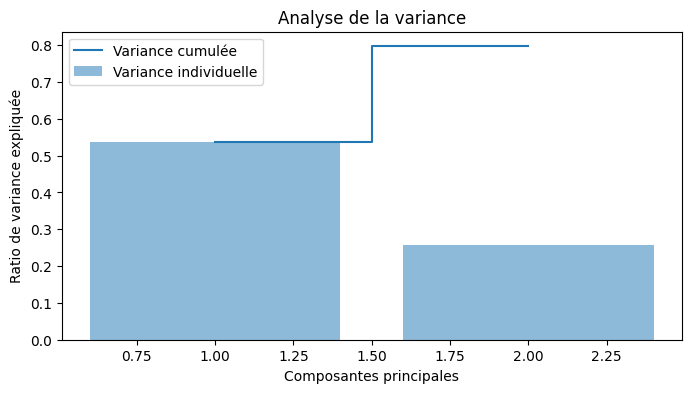

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Variance individuelle')
plt.step(range(1, 3), pca.explained_variance_ratio_.cumsum(), where='mid', label='Variance cumulée')
plt.ylabel('Ratio de variance expliquée')
plt.xlabel('Composantes principales')
plt.legend(loc='best')
plt.title('Analyse de la variance')
plt.show()

### Pourcentage de variance expliquée

In [33]:
variance_totale = pca.explained_variance_ratio_.sum() * 100

print(f"La Dimension 1 garde {pca.explained_variance_ratio_[0]*100:.2f}% d'information.")
print(f"La Dimension 2 garde {pca.explained_variance_ratio_[1]*100:.2f}% d'information.")

La Dimension 1 garde 53.81% d'information.
La Dimension 2 garde 25.83% d'information.


In [34]:
# Somme de la variance
somme_variance = pca.explained_variance_ratio_.sum()
print(f"Variance totale conservée : {somme_variance * 100:.2f}%")

Variance totale conservée : 79.64%


### Nuage de point, visualisation en 2D

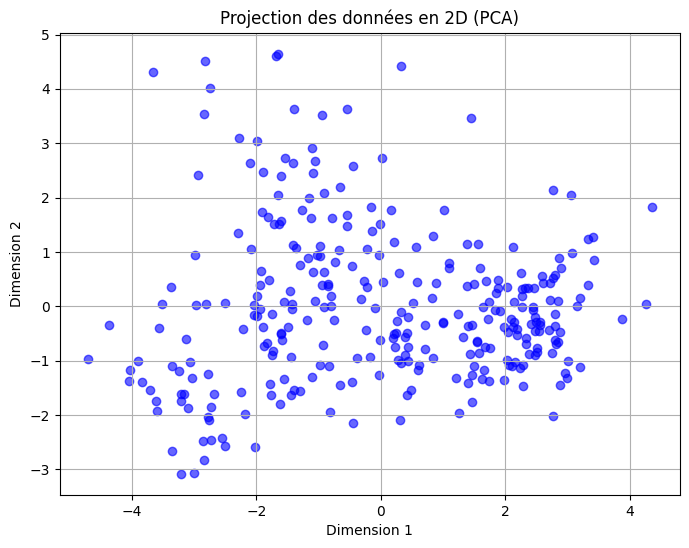

In [35]:
df_pca = pd.DataFrame(X_pca, columns=['Dim_1', 'Dim_2'])

plt.figure(figsize=(8, 6))
plt.scatter(df_pca['Dim_1'], df_pca['Dim_2'], alpha=0.6, c='blue')
plt.title('Projection des données en 2D (PCA)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)
plt.show()

### Analyse de la structure

Après réduction de dimension, on passe de 8 colonnes à 2 en gardant environ 80% de la variance, donc de l'information totale.
En regardant le nuage de point, on remarque que les points forment des groupes (de manière très légère). On remarque donc de formes densités dans certaines régions/villes. 

### Exporter les données en 2 dimensions

In [28]:
df_pca.to_csv('outputs/pca_city_lifestyle.csv', index=False)